In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features
import pandas as pd

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
apple = dataset.YahooFinance.get_ticker_data_incremental("AAPL", save_csv=True)

plots.summarize_df(apple)

Fetching full historical data for AAPL
Fetched 11424 rows for AAPL
Saved data for AAPL to AAPL.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 11424 entries, 1980-12-12 00:00:00-05:00 to 2026-04-13 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11424 non-null  float64
 1   High          11424 non-null  float64
 2   Low           11424 non-null  float64
 3   Close         11424 non-null  float64
 4   Adj Close     11424 non-null  float64
 5   Volume        11424 non-null  int64  
 6   Dividends     11424 non-null  float64
 7   Stock Splits  11424 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 803.2 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,11424.00000000,11424.00000000,11424.00000000,11424.00000000,11424.00000000,11424.00000000,11424.00000000,11424.00000000
mean,30.27030216,30.59686180,29.96039233,30.29154962,29.33997356,308142850.22759104,0.00088091,0.00148810
std,60.81995680,61.46865669,60.21510712,60.86840685,60.33487035,333023264.26071906,0.01314678,0.08208880
min,0.04966500,0.04966500,0.04910700,0.04910700,0.03760943,0.00000000,0.00000000,0.00000000
25%,0.30532926,0.31208675,0.29910699,0.30524600,0.24742797,105232400.00000000,0.00000000,0.00000000
50%,0.60937500,0.62165201,0.59821397,0.61160702,0.49706522,197120000.00000000,0.00000000,0.00000000
75%,24.61312532,24.82616043,24.35687447,24.59124994,21.96902084,388250800.00000000,0.00000000,0.00000000
max,286.20001221,288.61999512,283.29998779,286.19000244,285.92245483,7421640800.00000000,0.26000000,7.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12 00:00:00-05:00,0.12834799,0.12890600,0.12834799,0.12834799,0.09829748,469033600,0.00000000,0.00000000
1980-12-15 00:00:00-05:00,0.12221000,0.12221000,0.12165200,0.12165200,0.09316926,175884800,0.00000000,0.00000000
2026-04-10 00:00:00-04:00,259.98001099,262.19000244,259.01998901,260.48001099,260.48001099,31291500,0.00000000,0.00000000
2026-04-13 00:00:00-04:00,259.73001099,260.17999268,256.66000366,259.20001221,259.20001221,35196600,0.00000000,0.00000000


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [4]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28 00:00:00-04:00,126.01249695,121.17153931,0.00000000,0.00000000
2020-08-31 00:00:00-04:00,127.58000183,125.28070068,0.00000000,4.00000000
2020-09-01 00:00:00-04:00,132.75999451,130.27095032,0.00000000,0.00000000


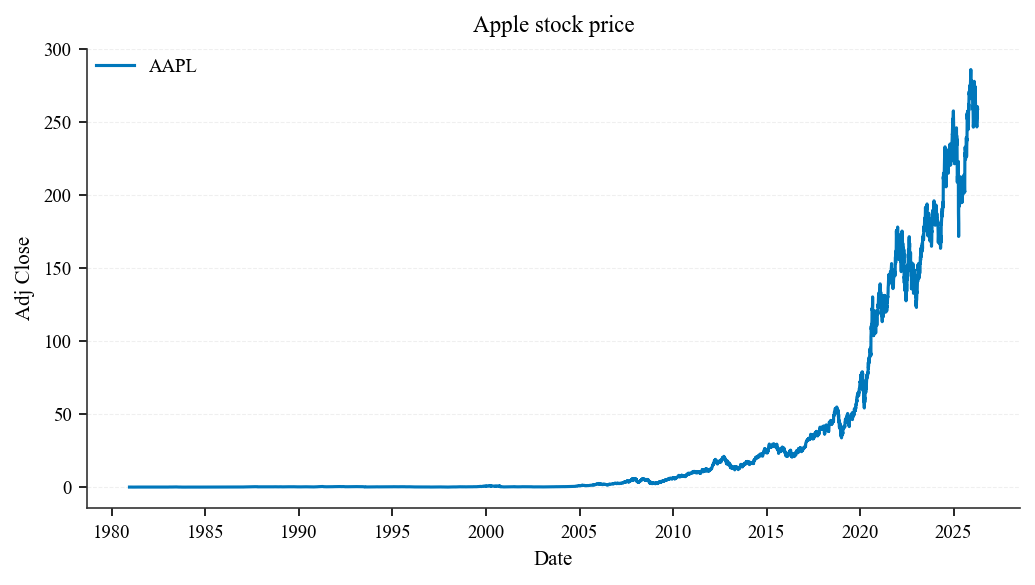

,AAPL
Date,
1980-12-12,0.09829748
1980-12-15,0.09316926
1980-12-16,0.08633082
1980-12-17,0.08846759
1980-12-18,0.09103248
...,...
2026-04-07,253.50000000
2026-04-08,258.89999390
2026-04-09,260.48999023


In [5]:
plots.YahooFinance.show_chart(apple, "AAPL", title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [6]:
SP500 = dataset.YahooFinance.get_ticker_data_incremental("^GSPC", save_csv=True)
SP500TR = dataset.YahooFinance.get_ticker_data_incremental("^SP500TR", save_csv=True)
ETF = dataset.YahooFinance.get_ticker_data_incremental("CSPX.L", save_csv=True)

plots.summarize_df(SP500)
plots.summarize_df(SP500TR)
plots.summarize_df(ETF)

Fetching full historical data for ^GSPC
Fetched 24686 rows for ^GSPC
Saved data for ^GSPC to ^GSPC.csv
Fetching full historical data for ^SP500TR
Fetched 9641 rows for ^SP500TR
Saved data for ^SP500TR to ^SP500TR.csv
Fetching full historical data for CSPX.L
Fetched 3932 rows for CSPX.L
Saved data for CSPX.L to CSPX.L.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24686 entries, 1927-12-30 00:00:00-05:00 to 2026-04-13 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24686 non-null  float64
 1   High          24686 non-null  float64
 2   Low           24686 non-null  float64
 3   Close         24686 non-null  float64
 4   Adj Close     24686 non-null  float64
 5   Volume        24686 non-null  int64  
 6   Dividends     24686 non-null  float64
 7   Stock Splits  24686 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7 MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000
mean,731.71951514,735.92388802,727.24044885,731.86826367,731.86826367,974906871.50611687,0.00000000,0.00000000
std,1256.11755167,1262.76739185,1248.92571426,1256.32800224,1256.32800224,1692535423.34978914,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1602500.00000000,0.00000000,0.00000000
50%,103.63499832,104.45999908,102.80000305,103.62500000,103.62500000,22370000.00000000,0.00000000,0.00000000
75%,1094.00250244,1099.71249390,1085.20755005,1093.82751465,1093.82751465,1189900000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 9641 entries, 1988-01-04 00:00:00-05:00 to 2026-04-13 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          9641 non-null   float64
 1   High          9641 non-null   float64
 2   Low           9641 non-null   float64
 3   Close         9641 non-null   float64
 4   Adj Close     9641 non-null   float64
 5   Volume        9641 non-null   int64  
 6   Dividends     9641 non-null   float64
 7   Stock Splits  9641 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 677.9 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,9641.00000000,9641.00000000,9641.00000000,9641.00000000,9641.00000000,9641.00000000,9641.00000000,9641.00000000
mean,3296.69780896,3310.72241347,3281.65549616,3297.26813465,3297.26813465,0.00000000,0.00000000,0.00000000
std,3435.86522088,3455.33891821,3414.76889351,3436.44020948,3436.44020948,0.00000000,0.00000000,0.00000000
min,242.86999512,242.86999512,242.86999512,242.86999512,242.86999512,0.00000000,0.00000000,0.00000000
25%,1169.68994141,1169.68994141,1169.68994141,1169.68994141,1169.68994141,0.00000000,0.00000000,0.00000000
50%,1917.54003906,1920.08996582,1914.41003418,1917.54003906,1917.54003906,0.00000000,0.00000000,0.00000000
75%,4100.16992188,4113.39990234,4084.83007812,4099.47021484,4099.47021484,0.00000000,0.00000000,0.00000000
max,15580.04003906,15580.58984375,15494.28027344,15527.82031250,15527.82031250,0.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 3932 entries, 2010-09-15 00:00:00+01:00 to 2026-04-13 00:00:00+01:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           3932 non-null   float64
 1   High           3932 non-null   float64
 2   Low            3932 non-null   float64
 3   Close          3932 non-null   float64
 4   Adj Close      3932 non-null   float64
 5   Volume         3932 non-null   int64  
 6   Dividends      3932 non-null   float64
 7   Stock Splits   3932 non-null   float64
 8   Capital Gains  3932 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 307.2 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000
mean,309.07794234,315.18824901,307.31315645,309.10717194,309.10717194,97044.44938962,0.00000000,0.00000000,0.00000000
std,172.99936716,183.77143337,171.93936295,173.03333864,173.03333864,118482.72161740,0.00000000,0.00000000,0.00000000
min,94.23999786,94.50000000,1.00000000,94.58499908,94.58499908,0.00000000,0.00000000,0.00000000,0.00000000
25%,176.54750061,177.38999939,175.31500626,176.35000610,176.35000610,19991.25000000,0.00000000,0.00000000,0.00000000
50%,262.80499268,263.80999756,261.44999695,262.84500122,262.84500122,73756.00000000,0.00000000,0.00000000,0.00000000
75%,428.89751434,430.81748962,426.62998962,428.56501007,428.56501007,128523.75000000,0.00000000,0.00000000,0.00000000
max,751.09002686,888.76000977,746.71417236,748.88000488,748.88000488,1665039.00000000,0.00000000,0.00000000,0.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-09-15 00:00:00+01:00,95.81999969,95.81999969,95.81999969,95.54000092,95.54000092,1,0.00000000,0.00000000,0.00000000
2010-09-16 00:00:00+01:00,95.54000092,95.54000092,95.54000092,95.54000092,95.54000092,0,0.00000000,0.00000000,0.00000000
2026-04-10 00:00:00+01:00,732.69000244,735.92999268,731.92999268,734.02001953,734.02001953,190766,0.00000000,0.00000000,0.00000000
2026-04-13 00:00:00+01:00,728.26000977,735.95867920,726.88000488,732.64001465,732.64001465,218558,0.00000000,0.00000000,0.00000000


Wyniki z kolumny Close i Adj Close są jednakowe.

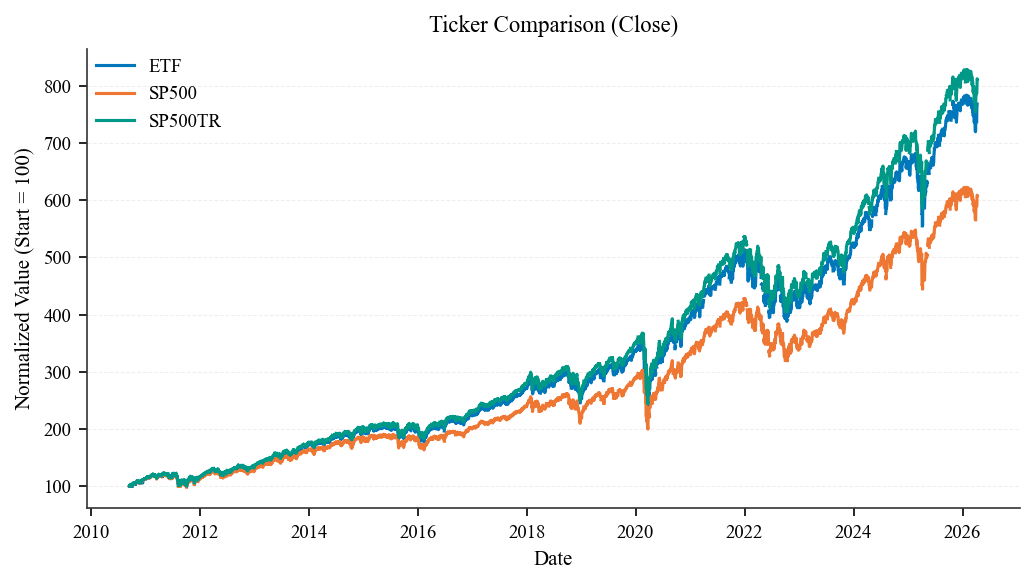

,ETF,SP500,SP500TR
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.00000000,100.35411389,100.35591222
2010-09-16,100.00000000,100.31755050,100.33616935
2010-09-17,NaN,100.40049865,100.41941377
2010-09-19,100.00000000,NaN,NaN
...,...,...,...
2026-04-07,760.58191980,590.21052910,787.62479905
2026-04-08,764.61168387,605.01384411,807.37970221
2026-04-09,768.28554794,608.74679376,812.41256324


In [7]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

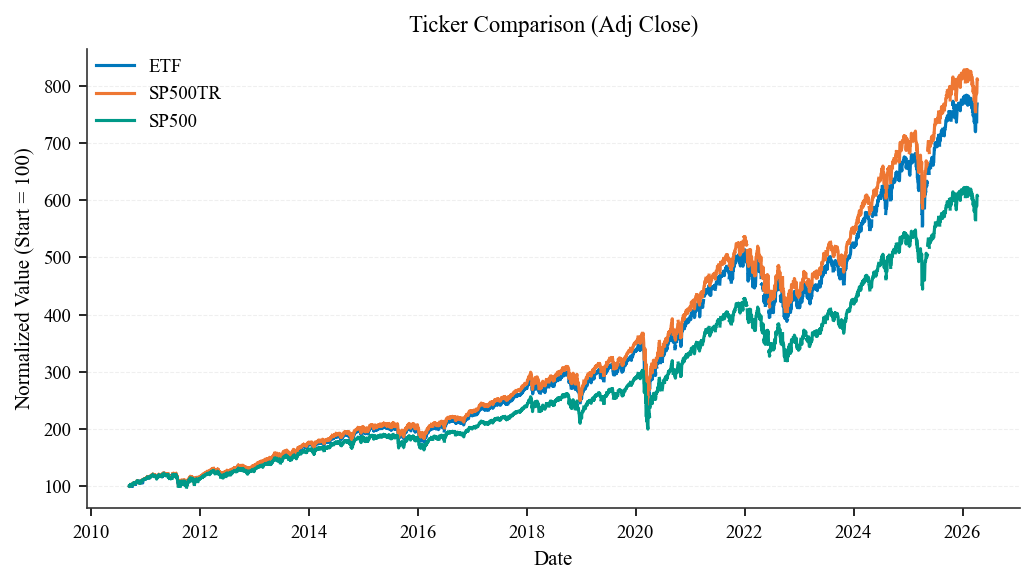

,ETF,SP500TR,SP500
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.00000000,100.35591222,100.35411389
2010-09-16,100.00000000,100.33616935,100.31755050
2010-09-17,NaN,100.41941377,100.40049865
2010-09-19,100.00000000,NaN,NaN
...,...,...,...
2026-04-07,760.58191980,787.62479905,590.21052910
2026-04-08,764.61168387,807.37970221,605.01384411
2026-04-09,768.28554794,812.41256324,608.74679376


In [8]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Saved benchmark to /home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/processed/benchmark_2026-04-14.csv
Deleted old file: benchmark_2026-04-13.csv
Deleted 1 old file(s) for benchmark
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24686 entries, 1927-12-30 00:00:00-05:00 to 2026-04-13 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24686 non-null  float64
 1   High          24686 non-null  float64
 2   Low           24686 non-null  float64
 3   Close         24686 non-null  float64
 4   Adj Close     24686 non-null  float64
 5   Volume        24686 non-null  int64  
 6   Dividends     24686 non-null  float64
 7   Stock Splits  24686 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7 MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000,24686.00000000
mean,731.71951514,735.92388802,727.24044885,731.86826367,731.86826367,974906871.50611687,0.00000000,0.00000000
std,1256.11755167,1262.76739185,1248.92571426,1256.32800224,1256.32800224,1692535423.34978914,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1602500.00000000,0.00000000,0.00000000
50%,103.63499832,104.45999908,102.80000305,103.62500000,103.62500000,22370000.00000000,0.00000000,0.00000000
75%,1094.00250244,1099.71249390,1085.20755005,1093.82751465,1093.82751465,1189900000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


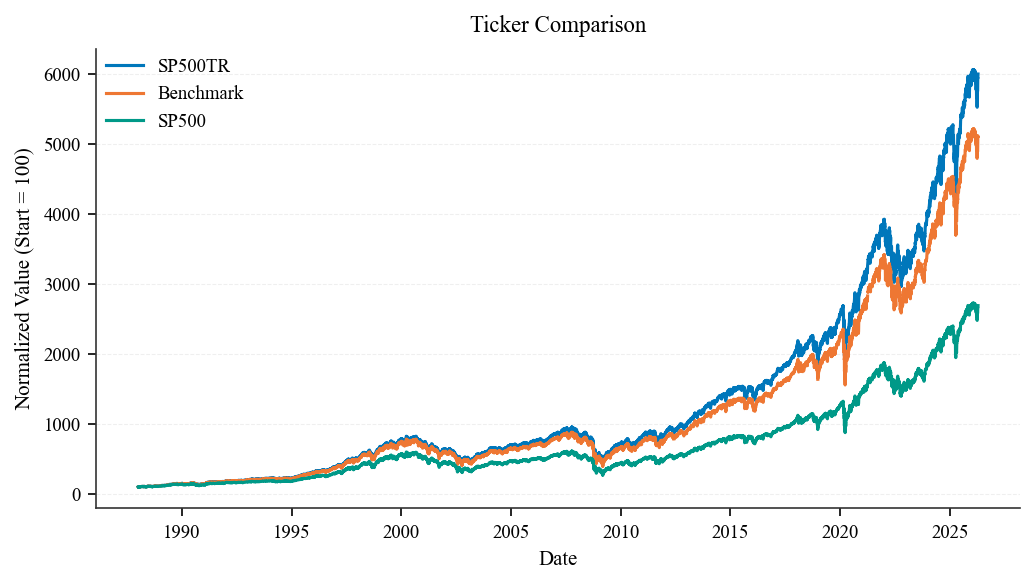

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07247111,101.05102853
1988-01-06,101.17569326,101.17236242,101.15261865
1988-01-07,102.02718642,102.02214814,102.00437791
1988-01-08,95.12929205,95.12302857,95.10041087
...,...,...,...
2026-04-07,5765.42468629,4911.71122243,2585.31297747
2026-04-08,5910.03085730,5066.92762817,2650.15628424
2026-04-09,5946.87147131,5093.77355012,2666.50781087


In [9]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

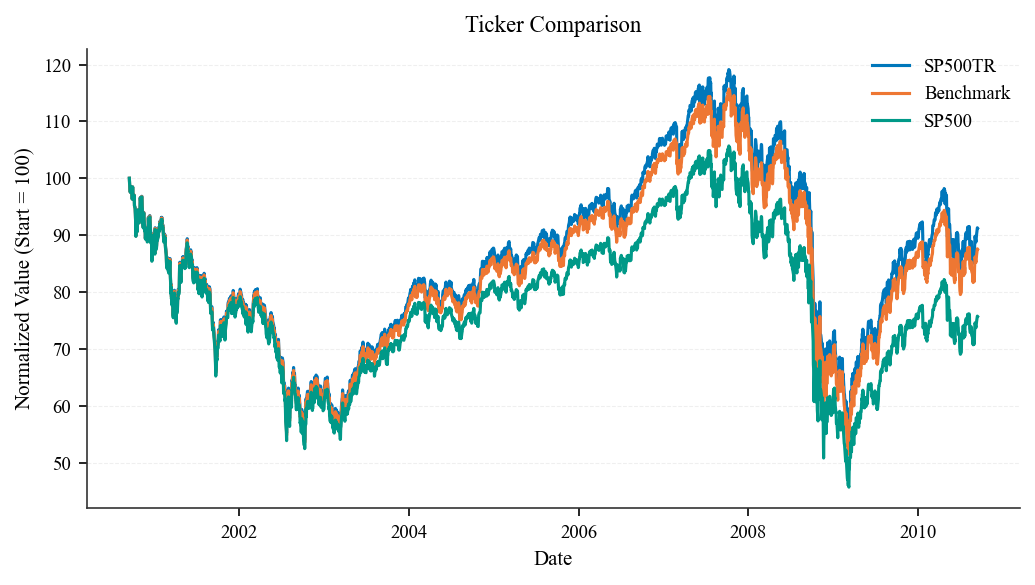

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98143397,98.98303453
2000-09-18,97.54650677,97.54329540,97.54468755
2000-09-19,98.58632187,98.58145351,98.58394250
2000-09-20,98.01042757,98.00397439,98.00589995
...,...,...,...
2010-09-08,89.38764760,85.77108235,74.20435276
2010-09-09,89.81993082,86.18445698,74.56292972
2010-09-10,90.25854274,86.60389043,74.92555407


In [10]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

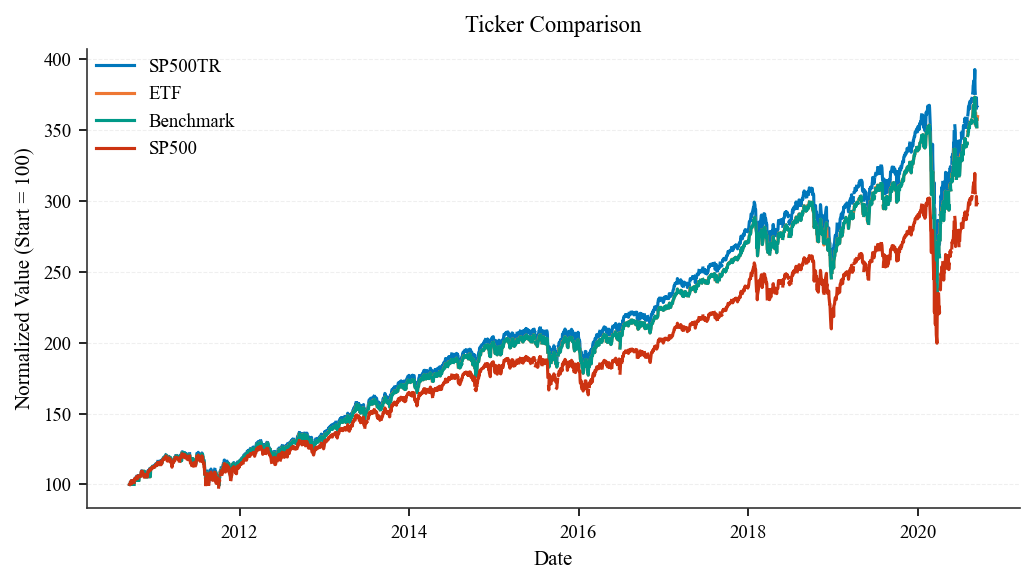

,SP500TR,ETF,Benchmark,SP500
Date,,,,
2010-09-14,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.00000000,100.40049865
2010-09-19,NaN,100.00000000,NaN,NaN
...,...,...,...,...
2020-09-09,372.81211299,357.89197132,357.72449837,303.18080768
2020-09-10,366.27394800,352.26081701,357.89197132,297.84943485
2020-09-11,366.48686611,NaN,352.26081701,298.00821010


In [11]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

Fetching full historical data for ^SP500EW
Fetched 4850 rows for ^SP500EW
Saved data for ^SP500EW to ^SP500EW.csv
Fetching full historical data for RSP
Fetched 5774 rows for RSP
Saved data for RSP to RSP.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 4850 entries, 2006-12-08 00:00:00-05:00 to 2026-04-13 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4850 non-null   float64
 1   High          4850 non-null   float64
 2   Low           4850 non-null   float64
 3   Close         4850 non-null   float64
 4   Adj Close     4850 non-null   float64
 5   Volume        4850 non-null   int64  
 6   Dividends     4850 non-null   float64
 7   Stock Splits  4850 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 341.0 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,4850.00000000,4850.00000000,4850.00000000,4850.00000000,4850.00000000,4850.00000000,4850.00000000,4850.00000000
mean,3802.73880837,3826.57616975,3778.30411347,3804.01020089,3804.01020089,0.78350515,0.00000000,0.00000000
std,1920.13394805,1930.57182702,1910.46495729,1920.93791501,1920.93791501,54.56482005,0.00000000,0.00000000
min,824.01000977,849.15997314,810.59997559,824.01000977,824.01000977,0.00000000,0.00000000,0.00000000
25%,2025.87747192,2036.04498291,2013.51751709,2026.21752930,2026.21752930,0.00000000,0.00000000,0.00000000
50%,3343.11499023,3354.06506348,3326.40490723,3343.67504883,3343.67504883,0.00000000,0.00000000,0.00000000
75%,5605.10498047,5662.23486328,5557.06750488,5606.64257812,5606.64257812,0.00000000,0.00000000,0.00000000
max,8289.28027344,8306.87988281,8219.33984375,8290.63964844,8290.63964844,3800.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 5774 entries, 2003-05-01 00:00:00-04:00 to 2026-04-13 00:00:00-04:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           5774 non-null   float64
 1   High           5774 non-null   float64
 2   Low            5774 non-null   float64
 3   Close          5774 non-null   float64
 4   Adj Close      5774 non-null   float64
 5   Volume         5774 non-null   int64  
 6   Dividends      5774 non-null   float64
 7   Stock Splits   5774 non-null   float64
 8   Capital Gains  5774 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 451.1 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,5774.00000000,5774.00000000,5774.00000000,5774.00000000,5774.00000000,5774.00000000,5774.00000000,5774.00000000,5774.00000000
mean,85.05619546,85.52356249,84.52881110,85.05805380,74.78356533,2081031.83235192,0.00540786,0.00069276,0.00000000
std,48.02968051,48.26923722,47.78536934,48.03513548,49.57456251,3722564.37723683,0.05081019,0.05264069,0.00000000
min,20.59000015,21.15999985,18.00000000,20.59000015,15.51315212,4400.00000000,0.00000000,0.00000000,0.00000000
25%,43.79999924,44.07062435,43.48187447,43.75999832,32.69374943,397925.00000000,0.00000000,0.00000000,0.00000000
50%,75.63999939,76.03499985,75.15500259,75.69499969,62.54138756,780950.00000000,0.00000000,0.00000000,0.00000000
75%,112.02499962,112.48749924,111.37999725,111.95250130,101.05258369,1986450.00000000,0.00000000,0.00000000,0.00000000
max,204.27000427,205.24000549,203.17999268,204.97000122,204.09623718,57508500.00000000,0.83100000,4.00000000,0.00000000


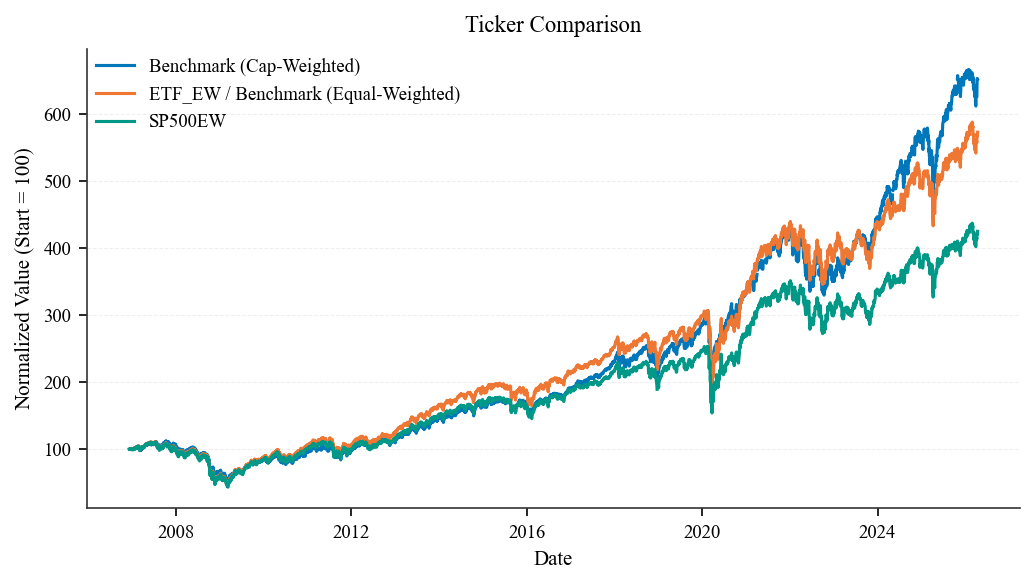

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22683133,100.04192001,100.08383243
2006-12-12,100.12292167,99.89497471,99.87873422
2006-12-13,100.25669562,100.06296243,99.92091110
2006-12-14,101.13345238,100.79776588,100.74660099
...,...,...,...
2026-04-07,626.65601792,557.34656753,413.33809017
2026-04-08,646.45915584,570.22237386,423.08868016
2026-04-09,649.88426733,570.56801893,423.31593202


In [12]:
SP500EW = dataset.YahooFinance.get_ticker_data_incremental("^SP500EW", save_csv=True)
ETF_EW = dataset.YahooFinance.get_ticker_data_incremental("RSP", save_csv=True)

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [13]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [16]:
tickers = dataset.tickers_from_sp500_components(sp500_components)

yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.download(tickers, save_csv=True)
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

$BLS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$CBSS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$AW: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)


Number of unique tickers extracted: 1194


$ALTR: possibly delisted; no timezone found
$CBH: possibly delisted; no timezone found
$AZA.A: possibly delisted; no timezone found
$AGC: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$ABKFQ: possibly delisted; no timezone found
$ABC: possibly delisted; no timezone found
$BSC: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ARNC: possibly delisted; no timezone found
$BT: possibly delisted; no timezone found
$ARG: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ACS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$BF.B: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$BTUUQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BMGCA"}}}
$AAMRQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ANTM: possibly del

$CVH: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$DF: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$DCNAQ: possibly delisted; no timezone found
$EKDKQ: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$DPHIQ: possibly delisted; no timezone found
$CFL: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$DALRQ: possibly delisted; no timezone found
$DNB: possibly delisted; no timezone found
$CCTYQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$CGP: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$EOP: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$DISCK: possibly delisted; no timezone found
$COG: possibly delisted; no timezone found
$COV: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ETFC: possibly delisted; no timezone found
$ENRNQ: possibl

$HFS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$JNS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HES: possibly delisted; no timezone found
$GRA: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$GMCR: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HPH: possibly delisted; no timezone found
$FTL.A: possibly delisted; no timezone found
$JOS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FLMIQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$JH: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$I: possibly delisted; no timezone found
$JOY: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FDO: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$GIDL: possibly delisted; no timezone found
$GPU: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$GTW: possib

$MYG: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$NVLS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$K: possibly delisted; no timezone found
$MDP: possibly delisted; no timezone found
$LXK: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$LVLT: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$NBL: possibly delisted; no timezone found
$LLX: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MIL: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$JP: possibly delisted; no timezone found
$OAT: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$KSE: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MYL: possibly delisted; no timezone found
$LSI: possibly delisted; no timezone found
$MKG: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MWW: possibly delisted; no price data found  (1d 1927-05-0

$PVT: possibly delisted; no timezone found
$ONE: possibly delisted; no timezone found
$SHN: possibly delisted; no timezone found
$PARA: possibly delisted; no timezone found
$PHA: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SFA: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$PCP: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SIVB: possibly delisted; no timezone found
$PEAK: possibly delisted; no timezone found
SRCL: Period 'max' is invalid, must be one of: 1d, 5d
$PBCT: possibly delisted; no timezone found
$OMX: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SBL: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$PLL: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$SFS: possibly delisted; no timezone found
$SNI: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$RHT: possibly delisted; no timezone found
$RSHCQ: possi

$WWY: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$YNR: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$WBA: possibly delisted; no timezone found
$TA: possibly delisted; no timezone found
$USHC: possibly delisted; no timezone found
$UAWGQ: possibly delisted; no timezone found
$TMK: possibly delisted; no timezone found
$VSTNQ: possibly delisted; no timezone found
$TRB: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$TIN: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$TCOMA: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$WFM: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$WCOEQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SYMC: possibly delisted; no timezone found
$XTO: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SWN: possibly delisted; no timezone found
$UTX: possibly delisted; no timezone fo

Saved Close.csv (16177 rows x 1194 columns)
Saved Open.csv (16177 rows x 1194 columns)
Saved High.csv (16177 rows x 1194 columns)
Saved Low.csv (16177 rows x 1194 columns)
Saved Volume.csv (16177 rows x 1194 columns)
Saved Adj_Close.csv (16177 rows x 1194 columns)
Saved Dividends.csv (16177 rows x 820 columns)
Saved Stock_Splits.csv (16177 rows x 820 columns)
YahooFinance per-ticker status:
  A: downloaded
  AABA: downloaded
  AAL: downloaded
  AAMRQ: downloaded
  AAP: downloaded
  AAPL: downloaded
  ABBV: downloaded
  ABC: downloaded
  ABI: downloaded
  ABKFQ: downloaded
  ABMD: downloaded
  ABNB: downloaded
  ABS: downloaded
  ABT: downloaded
  ABX: downloaded
  ACAS: downloaded
  ACGL: downloaded
  ACKH: downloaded
  ACN: downloaded
  ACS: downloaded
  ACV: downloaded
  ADBE: downloaded
  ADCT: downloaded
  ADI: downloaded
  ADM: downloaded
  ADP: downloaded
  ADS: downloaded
  ADSK: downloaded
  ADT: downloaded
  AEE: downloaded
  AEP: downloaded
  AES: downloaded
  AET: downloaded

#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

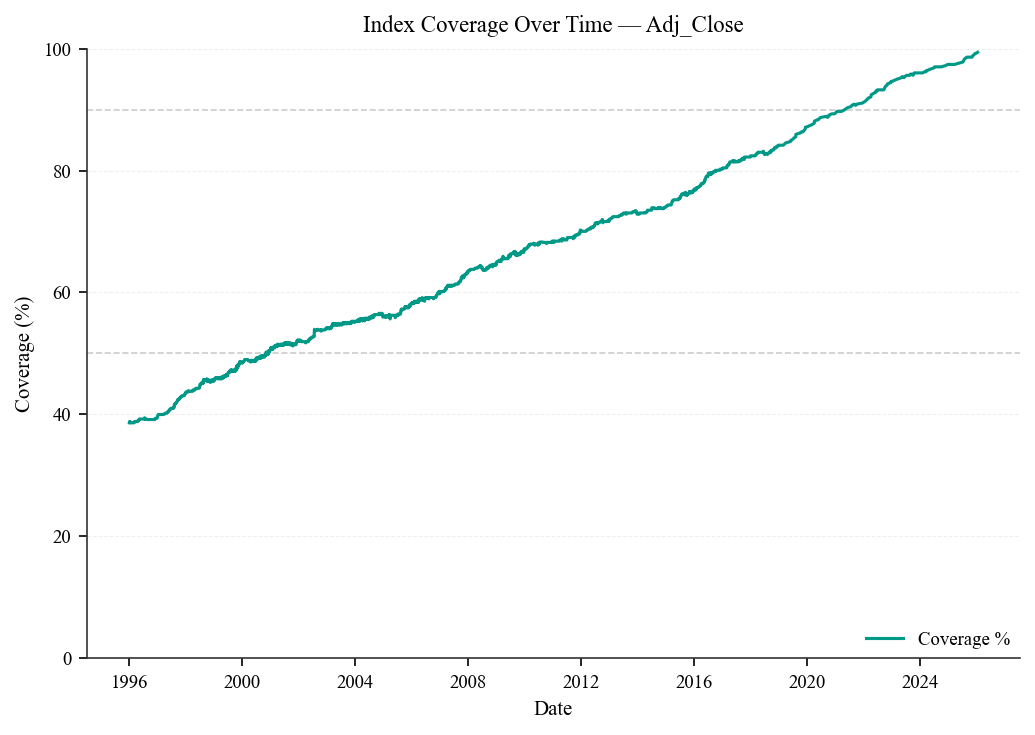

Missing ticker coverage periods:
- AABA:
  missing from 1999-12-08 to 2017-06-16
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABC:
  missing from 2001-08-30 to 2023-08-25
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABMD:
  missing from 2018-05-31 to 2022-12-19
- ABS:
  missing from 1996-01-02 to 2006-05-31
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACAS:
  missing from 2007-07-09 to 2009-03-02
- ACKH:
  missing from 1996-01-02 to 2000-11-08
- ACS:
  missing from 2004-04-02 to 2010-02-02
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADS:
  missing from 2013-12-23 to 2020-05-22
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AEE:
  missing from 1996-01-02 to 1997-12-31
- AET:
  missing from 1996-01-02 to 2018-11-28
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AGN:
  missing

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.50055453,184.24879852,0.00000000,496.74935305,62.77348877
std,72.76614649,67.95654165,0.00000000,5.16624733,14.02972198
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [19]:
import importlib
importlib.reload(plots)

coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)